# Análise de Explicabilidade (XAI) e Discussão dos Resultados

Este notebook consolida a etapa de análise interpretativa do modelo CNN-LSTM aplicado à manutenção prescritiva no contexto da Indústria 4.0. 

As perguntas à serem respondidas nesse notabook são:

1. **Quais sensores dominam a previsão?**

2. **Como essa importância muda ao longo do tempo?**

3. **Existe mudança de importância conforme a complexidade do dataset?**

4. **Existe consenso entre diferentes modelos?**

5. **Avaliando a estabilidade: Treinando o modelo 30 vezes, as explicações permanecem iguais?**

6. **Quando o modelo erra muito, qual sensor causou isso?**


Para responder a essas questões, utilizaremos o pipeline modular construído no diretório `src/xai/`, que integra métodos de atribuição de importância (SHAP, TimeSHAP, WindowSHAP) e métodos baseados em gradientes (Grad-CAM e Saliency Maps).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath('../..')) 

from src.xai.xai_baseExplainer import BaseExplainer
from src.xai.xai_shapExplainer import ShapExplainer
from src.xai.xai_limeExplainer import LimeExplainer
from src.xai.xai_igExplainer import IntegratedGradientsExplainer
from src.xai.xai_timeshapExplainer import TimeShapExplainer
from src.xai.xai_windowshapExplainer import WindowShapExplainer
from src.xai.xaI_gradcamExplainer import GradCamExplainer
from src.xai.xai_saliencymapsExplainer import SaliencyMapsExplainer

In [2]:
DATASET_01 = "FD001"
model_path_001 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_01}.keras"
x_path_001 = f"../../data/processed_data/X_test_{DATASET_01}.npz"
y_path_001 = f"../../data/processed_data/y_test_{DATASET_01}.npz"

DATASET_02 = "FD002"
model_path_002 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_02}.keras"
x_path_002 = f"../../data/processed_data/X_test_{DATASET_02}.npz"
y_path_002 = f"../../data/processed_data/y_test_{DATASET_02}.npz"

DATASET_03 = "FD003"
model_path_003 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_03}.keras"
x_path_003 = f"../../data/processed_data/X_test_{DATASET_03}.npz"
y_path_003 = f"../../data/processed_data/y_test_{DATASET_03}.npz"

DATASET_04 = "FD004"
model_path_004 = f"../../models/best_models_cnn_lstm/best_cnn_lstm_{DATASET_04}.keras"
x_path_004 = f"../../data/processed_data/X_test_{DATASET_04}.npz"
y_path_004 = f"../../data/processed_data/y_test_{DATASET_04}.npz"

## 1. Quais sensores dominam a previsão?

Para responder a esta pergunta, aplicaremos os métodos SHAP, Saliency Maps e Integrated Gradients. 

O objetivo é cruzar os resultados abordagens independentes de XAI, se os métodos convergirem para o mesmo grupo de sensores, teremos uma forte evidência de que essas variáveis são, de fato, os principais indicadores físicos da degradação do motor aprendidos pela CNN-LSTM. Utilizando três métodos facilita caso aconteça um empate no sensor vencedor.

A ideia foi criar uma tabela, com um ranking dos sensores que mais impactam em cada método de XAI, de forma que no final é gerado um consenso com os sensores mais impactantes considerando todos métodos de XAI

In [27]:
shap_explainer_001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)
saliency_explainer_001 = SaliencyMapsExplainer(model_path_001, x_path_001, y_path_001)
ig_explainer_001 = IntegratedGradientsExplainer(model_path_001, x_path_001, y_path_001)

#shap_explainer.plot_global_summary(num_samples=100)

#saliency_explainer.plot_global_summary(num_samples=100)

#ig_explainer.plot_global_summary(num_samples=100)

In [28]:
def gerar_tabela_consenso(shap_explainer, saliency_explainer, ig_explainer, feature_names, num_samples=100):
    print(f"Extraindo dados de {num_samples} amostras para a Tabela de Consenso (aguarde)...")
    
    n_sensores = shap_explainer.X_test.shape[2]
    
    shap_importances = np.zeros(n_sensores)
    saliency_importances = np.zeros(n_sensores)
    ig_importances = np.zeros(n_sensores)
           
    for i in range(num_samples):

        sv = shap_explainer.explain_instance(i)
        if sv.ndim == 4:
            sv = sv[0, :, :, 0]
        shap_importances += np.sum(np.abs(sv), axis=0)

        sal = saliency_explainer.explain_instance(i)
        saliency_importances += np.sum(sal, axis=0) 

        ig = ig_explainer.explain_instance(i)
        ig_importances += np.sum(np.abs(ig), axis=0)

    def get_top10_scores(importances):
        top_indices = np.argsort(importances)[-10:][::-1]
        scores = {}
        ranking = {}
        for rank, sensor_idx in enumerate(top_indices):
            nome_sensor = feature_names[sensor_idx] 
            scores[nome_sensor] = 10 - rank
            ranking[nome_sensor] = rank + 1
        return scores, ranking

    shap_scores, shap_rank = get_top10_scores(shap_importances)
    sal_scores, sal_rank = get_top10_scores(saliency_importances)
    ig_scores, ig_rank = get_top10_scores(ig_importances)

    consenso = {}

    for sensor in feature_names:
        score_total = shap_scores.get(sensor, 0) + sal_scores.get(sensor, 0) + ig_scores.get(sensor, 0)
        
        if score_total > 0:
            consenso[sensor] = {
                "Pontuação Final": score_total,
                "Ranking (SHAP)": shap_rank.get(sensor, "-"),
                "Ranking (Saliency)": sal_rank.get(sensor, "-"),
                "Ranking (IG)": ig_rank.get(sensor, "-")
            }

    df_consenso = pd.DataFrame.from_dict(consenso, orient='index')
    if not df_consenso.empty:
        df_consenso = df_consenso.sort_values(by="Pontuação Final", ascending=False).head(5)
        
    return df_consenso

In [29]:
nomes_reais_fd001 = np.load(x_path_001)['features']

df_fd001 = gerar_tabela_consenso(shap_explainer_001, saliency_explainer_001, ig_explainer_001, feature_names=nomes_reais_fd001, num_samples=1000)
df_fd001

Extraindo dados de 1000 amostras para a Tabela de Consenso (aguarde)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(50, 30, 19))']
  warnings.warn(msg)


,Pontuação Final,Ranking (SHAP),Ranking (Saliency),Ranking (IG)
s_11,27,1,2,3
s_12,27,2,3,1
s_7,23,3,5,2
s_15,20,4,4,5
s_4,16,5,6,6


In [30]:
shap_explainer_002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)
saliency_explainer_002 = SaliencyMapsExplainer(model_path_002, x_path_002, y_path_002)
ig_explainer_002 = IntegratedGradientsExplainer(model_path_002, x_path_002, y_path_002)

nomes_reais_fd002 = np.load(x_path_002)['features']

df_fd002 = gerar_tabela_consenso(shap_explainer_002, saliency_explainer_002, ig_explainer_002, feature_names=nomes_reais_fd002, num_samples=1000)
df_fd002

Extraindo dados de 1000 amostras para a Tabela de Consenso (aguarde)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_61
Received: inputs=['Tensor(shape=(1, 30, 24))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_61
Received: inputs=['Tensor(shape=(50, 30, 24))']
  warnings.warn(msg)


,Pontuação Final,Ranking (SHAP),Ranking (Saliency),Ranking (IG)
s_11,30,1,1,1
s_15,27,2,2,2
s_4,24,3,3,3
s_7,21,4,4,4
s_17,16,6,5,6


In [31]:
shap_explainer_003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)
saliency_explainer_003 = SaliencyMapsExplainer(model_path_003, x_path_003, y_path_003)
ig_explainer_003 = IntegratedGradientsExplainer(model_path_003, x_path_003, y_path_003)

nomes_reais_fd003 = np.load(x_path_003)['features']

df_fd003 = gerar_tabela_consenso(shap_explainer_003, saliency_explainer_003, ig_explainer_003, feature_names=nomes_reais_fd003, num_samples=1000)
df_fd003

Extraindo dados de 1000 amostras para a Tabela de Consenso (aguarde)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_92
Received: inputs=['Tensor(shape=(1, 30, 20))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_92
Received: inputs=['Tensor(shape=(50, 30, 20))']
  warnings.warn(msg)


,Pontuação Final,Ranking (SHAP),Ranking (Saliency),Ranking (IG)
s_6,27,2,3,1
s_12,27,1,2,3
s_7,24,3,1,5
s_13,21,6,4,2
s_11,17,4,6,6


In [32]:
shap_explainer_004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)
saliency_explainer_004 = SaliencyMapsExplainer(model_path_004, x_path_004, y_path_004)
ig_explainer_004 = IntegratedGradientsExplainer(model_path_004, x_path_004, y_path_004)

nomes_reais_fd004 = np.load(x_path_004)['features']

df_fd004 = gerar_tabela_consenso(shap_explainer_004, saliency_explainer_004, ig_explainer_004, feature_names=nomes_reais_fd004, num_samples=1000)
df_fd004

Extraindo dados de 1000 amostras para a Tabela de Consenso (aguarde)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_123
Received: inputs=['Tensor(shape=(1, 30, 24))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_123
Received: inputs=['Tensor(shape=(50, 30, 24))']
  warnings.warn(msg)


,Pontuação Final,Ranking (SHAP),Ranking (Saliency),Ranking (IG)
s_11,29,1,2,1
s_9,25,3,1,4
s_4,23,2,6,2
s_12,21,4,3,5
s_7,16,6,5,6


### Tabela Cruzada — Consenso entre Datasets

Consolida os top-5 de cada base (FD001-FD004) num único quadro: uma linha por sensor, uma coluna por dataset com a posição no ranking daquela base (1 = mais importante), `-` quando o sensor não entrou no top 5, e uma coluna com em quantas bases o sensor aparece. Ordenado por esse total (desempate pela posição média — quanto menor, melhor).

In [33]:
resultados_por_dataset = {
    "FD001": df_fd001,
    "FD002": df_fd002,
    "FD003": df_fd003,
    "FD004": df_fd004,
}

sensores_unicos = sorted(set().union(*[df.index for df in resultados_por_dataset.values()]))

tabela_cruzada = pd.DataFrame(index=sensores_unicos)

for nome_dataset, df in resultados_por_dataset.items():
    posicao = {sensor: rank + 1 for rank, sensor in enumerate(df.index)}
    tabela_cruzada[nome_dataset] = [posicao.get(s, np.nan) for s in sensores_unicos]

colunas_datasets = list(resultados_por_dataset.keys())
tabela_cruzada["Nº de bases"] = tabela_cruzada[colunas_datasets].notna().sum(axis=1)
tabela_cruzada["Posição média"] = tabela_cruzada[colunas_datasets].mean(axis=1, skipna=True)

tabela_cruzada = tabela_cruzada.sort_values(
    by=["Nº de bases", "Posição média"],
    ascending=[False, True]
)

tabela_cruzada[colunas_datasets] = tabela_cruzada[colunas_datasets].fillna("-")
tabela_cruzada

,FD001,FD002,FD003,FD004,Nº de bases,Posição média
s_11,1.0,1.0,5.0,1.0,4,2.000000
s_7,3.0,4.0,3.0,5.0,4,3.750000
s_12,2.0,-,2.0,4.0,3,2.666667
s_4,5.0,3.0,-,3.0,3,3.666667
s_15,4.0,2.0,-,-,2,3.000000
s_6,-,-,1.0,-,1,1.000000
s_9,-,-,-,2.0,1,2.000000
s_13,-,-,4.0,-,1,4.000000
s_17,-,5.0,-,-,1,5.000000


## 2. Como essa importância muda ao longo do tempo?

A ideia é analisar, se a rede considera que ciclos mais recentes impactam mais no resultado do que os ciclos mais antigos. Para isso será usado o TimeSHAP, o WindowSHAP e Grad-CAM. 

O TimeSHAP ele funcionando retirando um ciclo para ver seu impacto, e assim é possível ver se os ciclos com maior impacto estão no final. Já o WindowSHAP ele agrupa os ciclos em blocos e podemos analisar se o bloco de maior impacto é o último. Para finalizar, o Grad-CAM ele mede em qual ciclo as ativações matemáticas da CNN foram mais fortes, servindo como complemento aos métodos anteriores.

In [34]:
time_shap_explainer_001 = TimeShapExplainer(model_path_001, x_path_001, y_path_001)
window_shap_explainer_001 = WindowShapExplainer(model_path_001, x_path_001, y_path_001)
gradcam_explainer_001 = GradCamExplainer(model_path_001, x_path_001, y_path_001)

Camada Convolucional identificada automaticamente: 'conv1d_30'


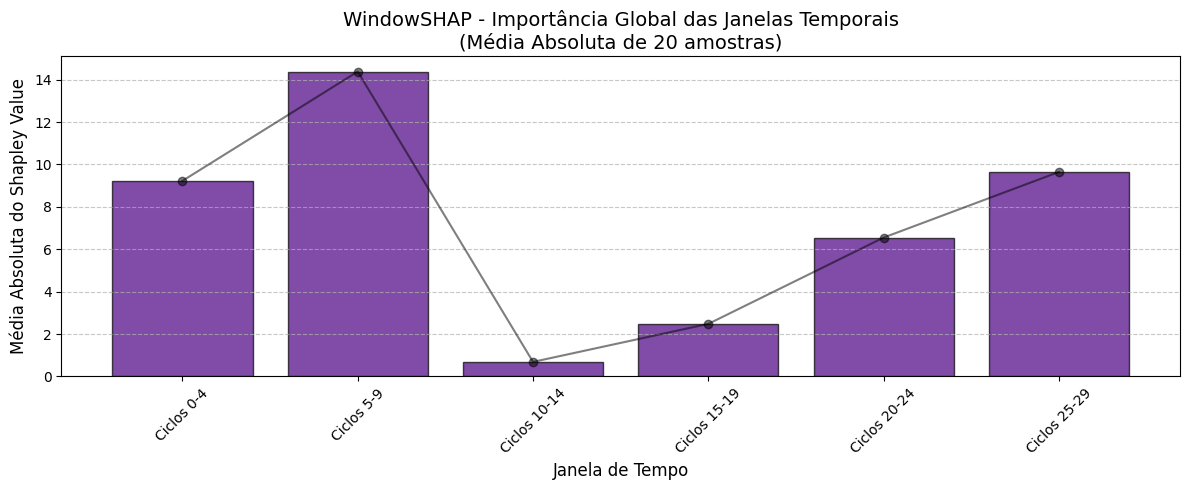

In [35]:
window_shap_explainer_001.plot_global_window_importance(num_instances=20, n_samples=1000)

Calculando Grad-CAM para 1000 amostras (isso pode levar alguns segundos)...


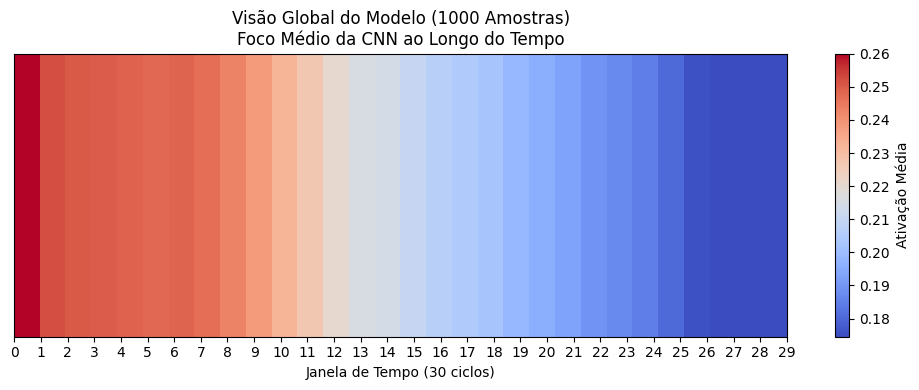

In [36]:
gradcam_explainer_001.plot_global_summary(num_samples=1000)

Calculando TimeSHAP Global para 20 amostras...


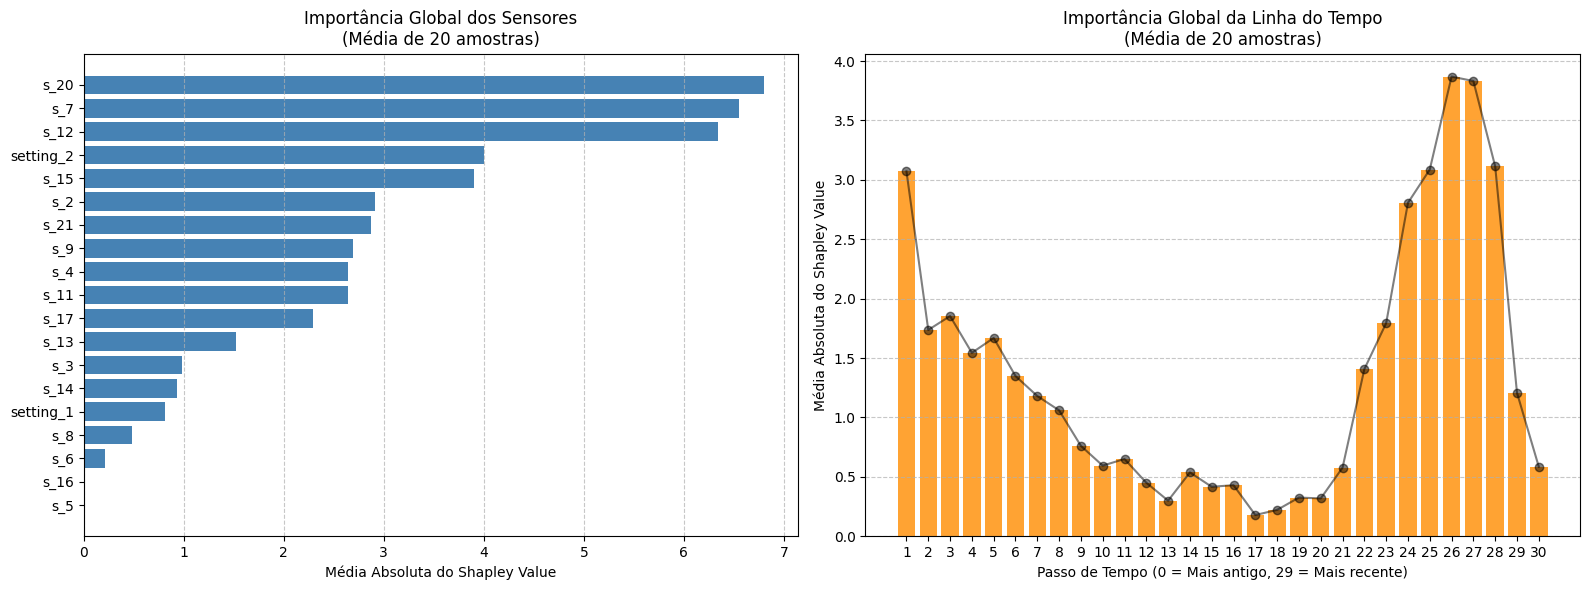

In [37]:
time_shap_explainer_001.plot_global_importance(num_instances=20, n_samples=1000)

O Grad-CAM mostra o início da janela como mais importante, e essa importância vai caindo aos poucos até o final. Já o TimeSHAP não segue só a ideia de quanto mais recente, mais importante, já que ele mostra dois picos: um no começo e outro perto do fim. Ou seja, o início ainda pesa bastante, não é só o fim que decide.

Camada Convolucional identificada automaticamente: 'conv1d_61'


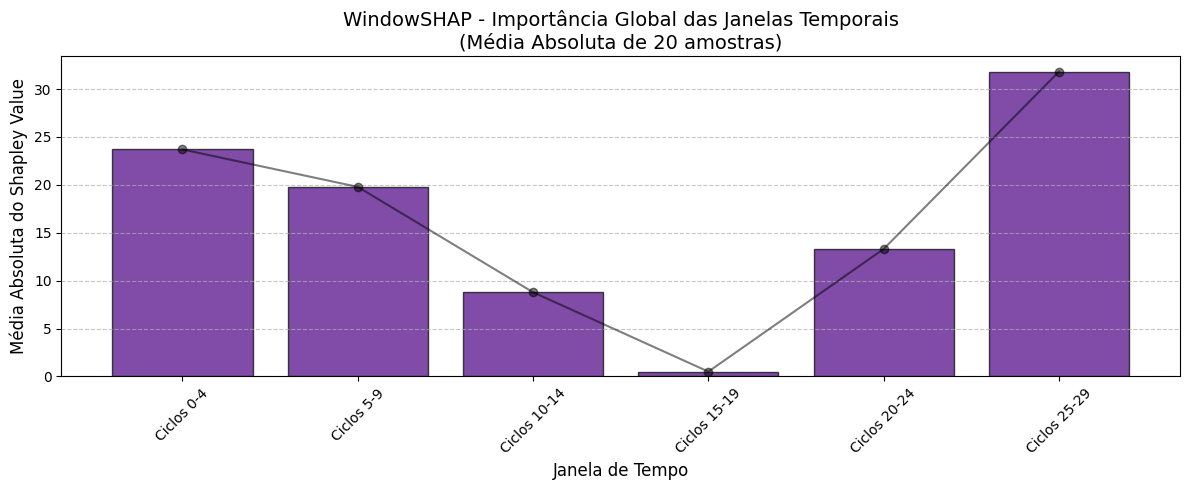

Calculando Grad-CAM para 1000 amostras (isso pode levar alguns segundos)...


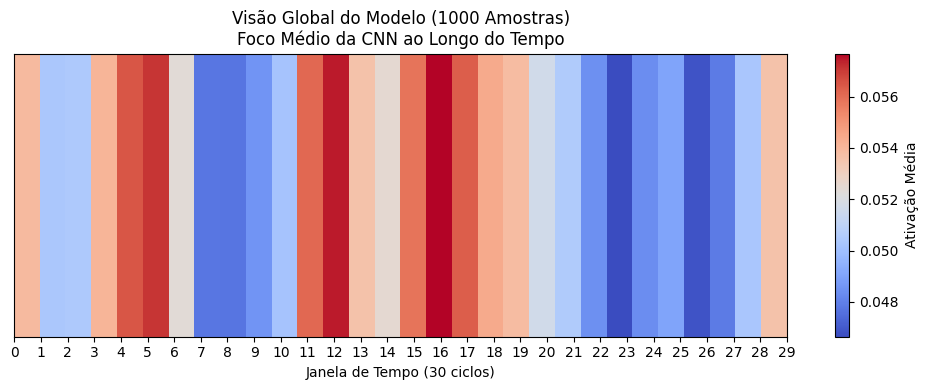

Calculando TimeSHAP Global para 20 amostras...


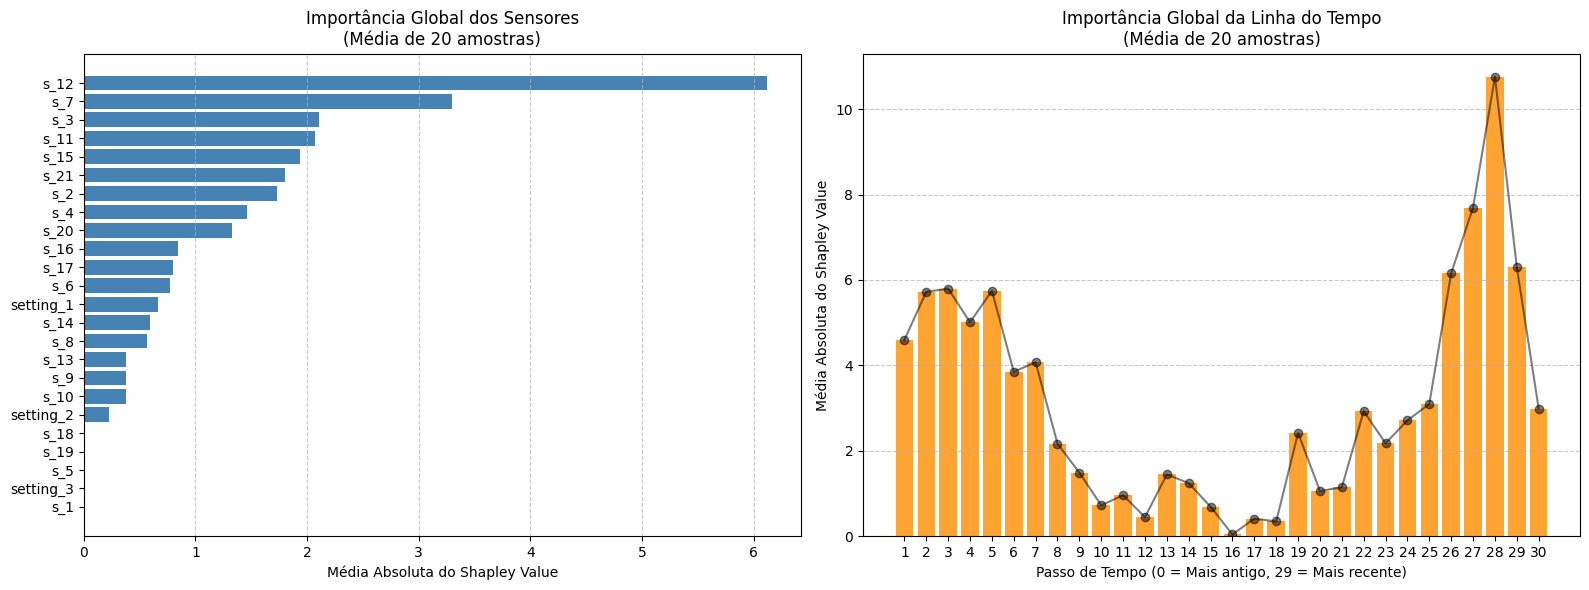

In [38]:
time_shap_explainer_002 = TimeShapExplainer(model_path_002, x_path_002, y_path_002)
window_shap_explainer_002 = WindowShapExplainer(model_path_002, x_path_002, y_path_002)
gradcam_explainer_002 = GradCamExplainer(model_path_002, x_path_002, y_path_002)

window_shap_explainer_002.plot_global_window_importance(num_instances=20, n_samples=1000)

gradcam_explainer_002.plot_global_summary(num_samples=1000)

time_shap_explainer_002.plot_global_importance(num_instances=20, n_samples=1000)

Aqui o Grad-CAM não repete o padrão da FD001, em vez de focar só no início, ele varia bastante ao longo da janela, com picos também no meio. Quem realmente aponta o início como importante é o WindowSHAP e o TimeSHAP, já que ambos possuem um pico no início e outro maior no final, demonstrando que esse modelo também estabelece uma "linha de base", mas as informações dos ciclos finais que fornecem as informações com maior peso para a predição da falha.

Camada Convolucional identificada automaticamente: 'conv1d_92'


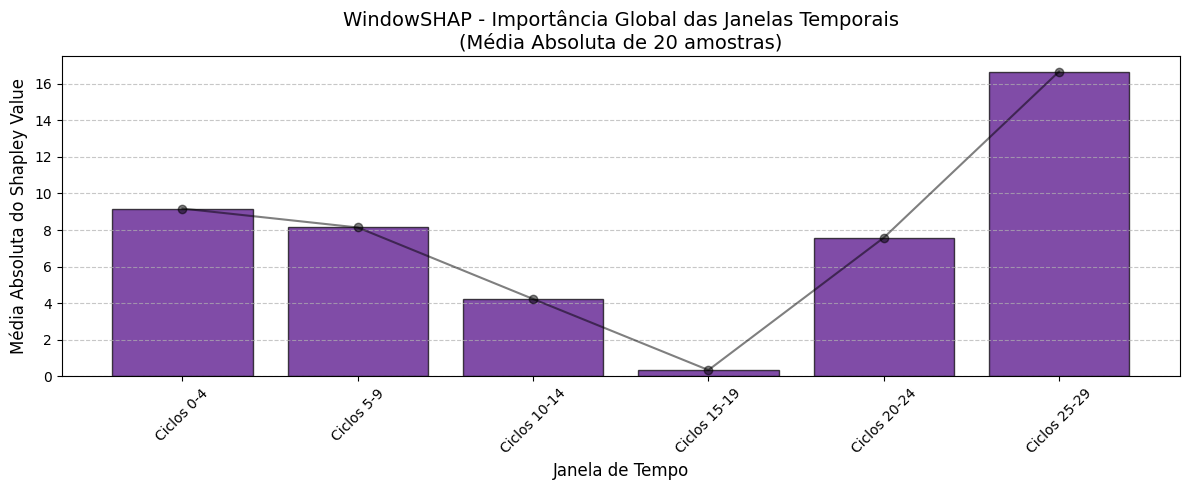

Calculando Grad-CAM para 1000 amostras (isso pode levar alguns segundos)...


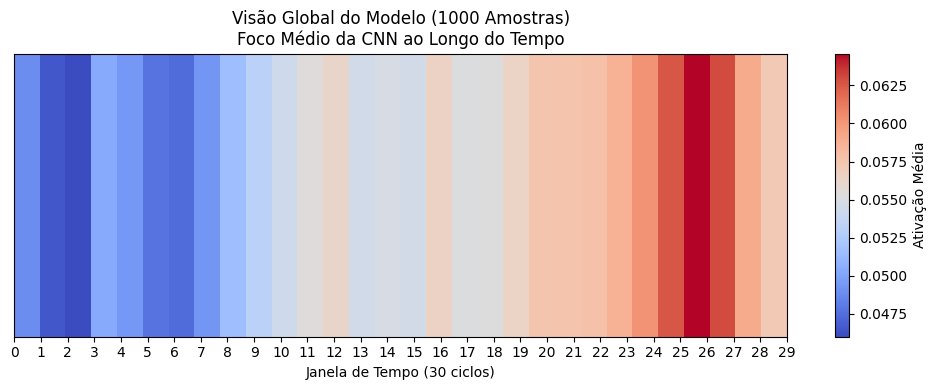

Calculando TimeSHAP Global para 20 amostras...


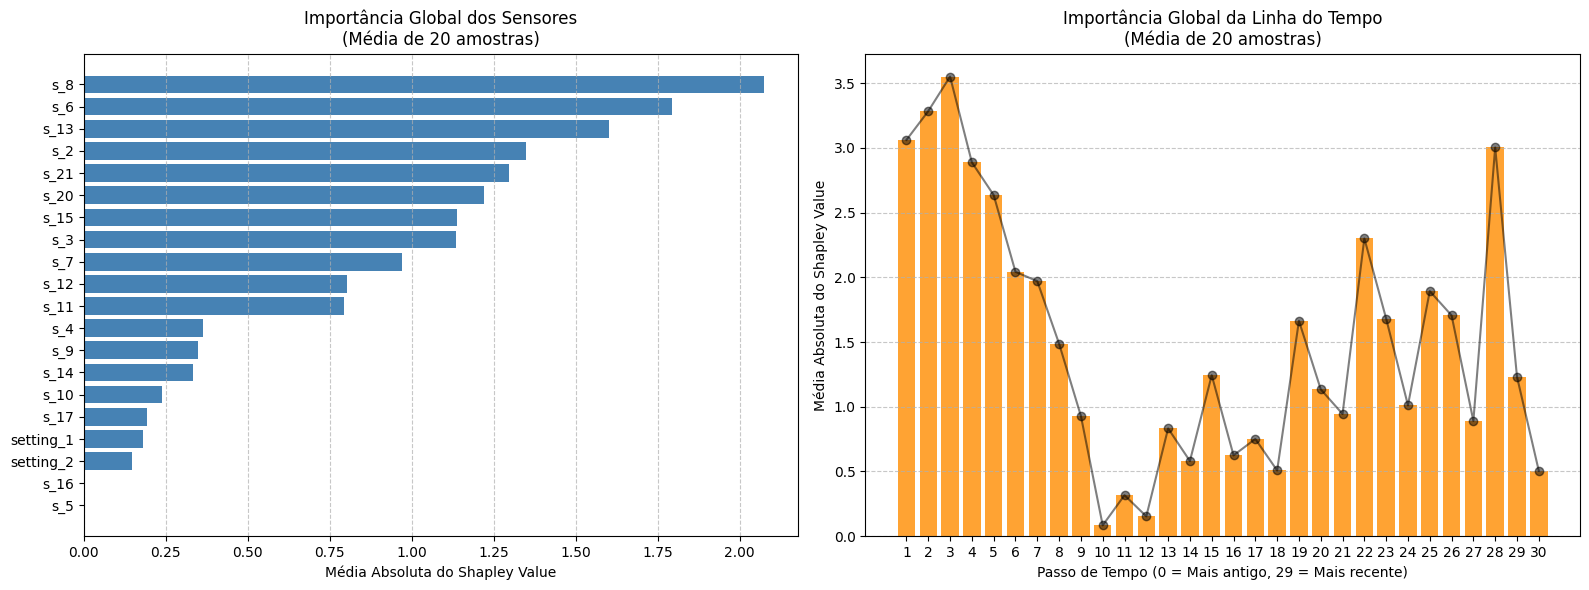

In [39]:
time_shap_explainer_003 = TimeShapExplainer(model_path_003, x_path_003, y_path_003)
window_shap_explainer_003 = WindowShapExplainer(model_path_003, x_path_003, y_path_003)
gradcam_explainer_003 = GradCamExplainer(model_path_003, x_path_003, y_path_003)

window_shap_explainer_003.plot_global_window_importance(num_instances=20, n_samples=1000)

gradcam_explainer_003.plot_global_summary(num_samples=1000)

time_shap_explainer_003.plot_global_importance(num_instances=20, n_samples=1000)

Com o segundo modo de falha, acontece o contrário do FD001, que tem o mesmo número de condições operacionais. O Grad-CAM demonstra um foco maior nos ciclos finais, enquanto o TimeSHAP te o pico mais impactante logo no começo.

Camada Convolucional identificada automaticamente: 'conv1d_123'


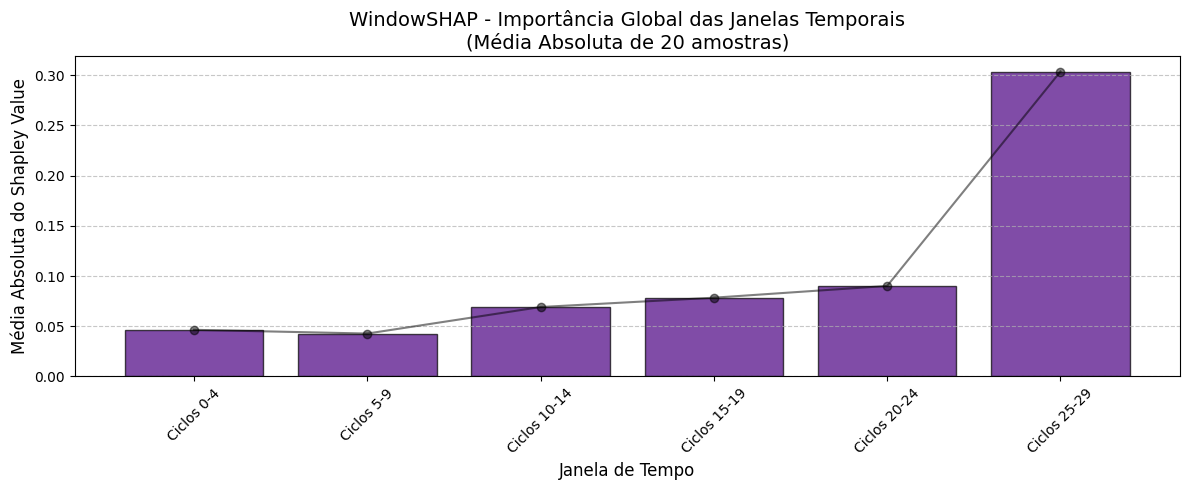

Calculando Grad-CAM para 1000 amostras (isso pode levar alguns segundos)...


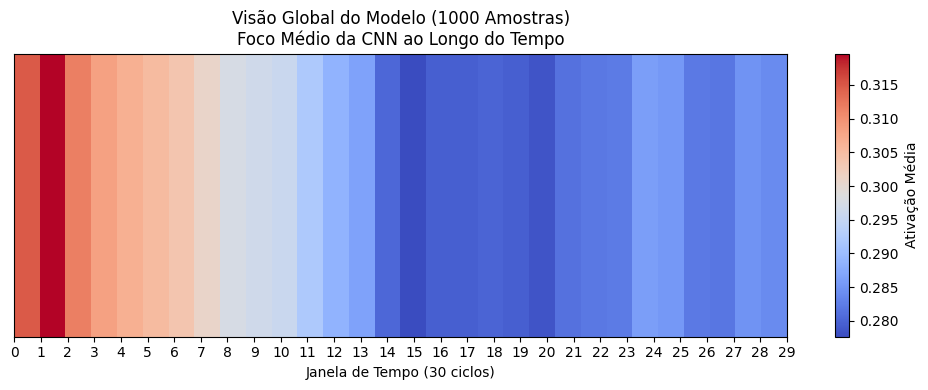

Calculando TimeSHAP Global para 20 amostras...


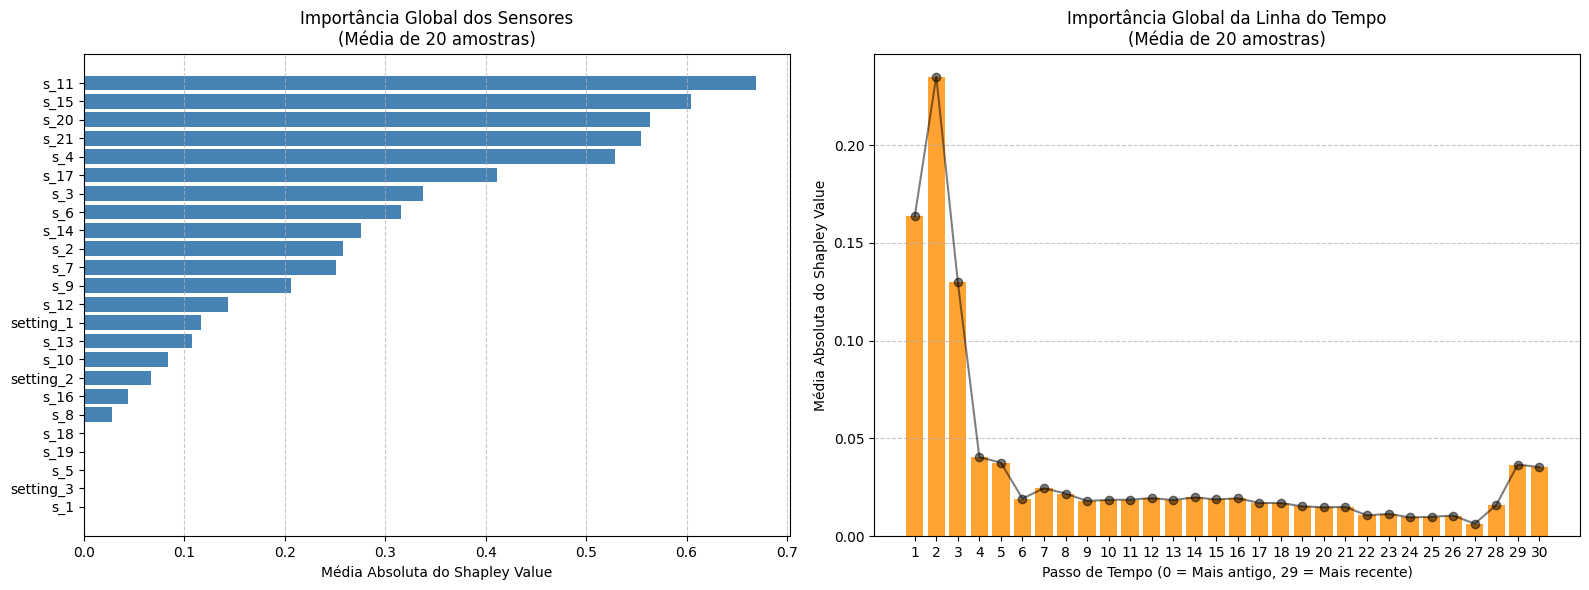

In [40]:
time_shap_explainer_004 = TimeShapExplainer(model_path_004, x_path_004, y_path_004)
window_shap_explainer_004 = WindowShapExplainer(model_path_004, x_path_004, y_path_004)
gradcam_explainer_004 = GradCamExplainer(model_path_004, x_path_004, y_path_004)

window_shap_explainer_004.plot_global_window_importance(num_instances=20, n_samples=1000)

gradcam_explainer_004.plot_global_summary(num_samples=1000)

time_shap_explainer_004.plot_global_importance(num_instances=20, n_samples=1000)

No cenário mais complexo do dataset, o Grad-CAM e o TimeSHAP demonstram uma dependência extrema dos primeiros ciclos da janela temporal, atuando como uma etapa indispensável para que o modelo identifique as bruscas mudanças de regime de operação. Já o WindowSHAP evidencia que o último bloco temporal (ciclos 25-29) concentra o maior peso preditivo macro, então a CNN-LSTM aprendeu a utilizar o início da janela para isolar as variáveis de voo e, em seguida, avalia o contraste com o desgaste mais recente de sensores críticos para calcular o RUL final.

## 3. Existe mudança de importância conforme a complexidade do dataset?

Quem muda: existe um núcleo pequeno de sensores que resiste à mudança de complexidade, o s_11 e s_7 que aparecem nos 4 datasets e o s_12 e s_4 com 3 aparições, mas isso é exceção, não regra: quase metade dos sensores que aparecem em algum top-5 só aparecem em um único dataset. Então a resposta é mista: alguns sensores são considerados mais importantes e impactantes e por esse motivo está presente em todos datasets, mas o restante da lista muda.

Quando muda: os gráficos da pergunta 2 mostram o Grad-CAM em posições bem diferentes em cada dataset, com foco no início na FD001, espalhado na FD002, foco no fim na FD003, e de volta pro início na FD004. Não segue uma regra simples tipo "mais condições operacionais = mais peso no fim", logo a complexidade claramente muda o comportamento do modelo, mas não de um jeito previsível. Já o TimeSHAP é possível analisar um ponto interessante, já que no FD001 e FD002 eles até tem um pico no começo, mas o do final é bem maior demonstrando um impacto mais importante nos ciclos finais. Enquanto nos modelos com 2 condições de falha, FD003 e FD004, o TimeSHAP identifica os ciclos iniciais como mais importantes para a predição da falha. O WindowSHAP contém um comportamento parecido nos 3 primeiros, com picos no começo e final, enquanto no modelo mais complexo(FD004) ele vai aumentando o valor do Shapley nos ciclos finais.

## 4. Existe consenso entre diferentes modelos?

SHAP, SaliencyMaps e IntegratedGradients: A análise da importância global dos sensores revela um forte consenso entre as diferentes técnicas de XAI. Embora a ordem exata do ranqueamento sofra pequenas mudanças naturais devido à diferença matemática de cada método, os sensores identificados como mais críticos estão sempre posicionados no topo em todos os modelos.

No FD002, o cenário demonstrou uma concordância excepcional. Todos os três métodos de XAI ranquearam os quatro sensores principais (s_11, s_15, s_4 e s_7) exatamente nas mesmas posições (1º ao 4º lugar, respectivamente), evidenciando uma extração de características extremamente nítida pela rede.

O fato de algoritmos de XAI com lógicas operacionais fundamentalmente distintas convergirem para o mesmo grupo de sensores vitais comprova que a CNN-LSTM baseia suas predições em padrões físicos reais da degradação termodinâmica e aerodinâmica, atestando a alta confiabilidade do modelo.


WindowSHAP, TimeSHAP e Grad-CAM: No eixo do tempo, o consenso entre as diferentes técnicas de XAI se manifesta de forma complementar. Em vez de apontarem unanimente para os mesmos ciclos individuais, o Grad-CAM, o TimeSHAP e o WindowSHAP revelam a necessidade de estabelecer uma linha de base para avaliar a severidade do desgaste recente.

O consenso entre as diferentes abordagens de XAI comprova que a CNN-LSTM aprendeu uma estratégia dinâmica sofisticada. A arquitetura utiliza as características do início da janela para mapear o contexto e isolar as variáveis de voo, realizando em seguida um contraste com o desgaste recente das assinaturas críticas para calcular o RUL.

## 5. Avaliando a estabilidade: Treinando o modelo 30 vezes, as explicações permanecem iguais?

### FD001

<div align="center">
  <img src="../../results/xai_estabilidade/estabilidade_FD001.png" alt="Estabilidade FD001" width="800">
</div>

O conjunto FD001 (condição de operação única e modo de falha único) atesta o comportamento ideal da arquitetura proposta. Os resultados demonstram uma estabilidade absoluta (presente 30 vezes em 30 testes) para os quatro sensores mais críticos do motor: s_11, s_15, s_7 e s_12. 

Isso comprova que, neste tipo de dado, o modelo sempre identifica esses 4 sensores como sensores de extrema importância para a predição. O último sensor do top 5 varia, mas na maioria dos casos (23/30) o s_4 foi o escolhido, com o s_2(6/30) e s_20(1/30) aparecendo poucas vezes

### FD002

<div align="center">
  <img src="../../results/xai_estabilidade/estabilidade_FD002.png" alt="Estabilidade FD002" width="800">
</div>

A introdução de múltiplas condições de voo no conjunto FD002 adiciona ruído e complexidade aos dados, o que naturalmente gera uma maior flutuação no ranqueamento dos sensores mais impactantes. No entanto, o modelo acaba mantendo um núcleo principal de sensores em destaque na grande maioria dos treinamentos.

Os sensores s_15 e s_11 lideram o consenso (aparecendo no Top 5 em 25 dos 30 testes), seguidos de perto pelo s_4 (24/30) e pelo s_12 (23/30), ou seja em cerca de 80% das inicializações esses sensores foram identificados como os mais impactantes. Vale notar que existem 11 sensores que apareceram no Top 5 em algum momento, mas com baixa frequência, o que pode ser reflexo do impacto dos ruídos e da complexidade dos dados, além da estocasticidade na inicialização dos pesos da rede.

### FD003

<div align="center">
  <img src="../../results/xai_estabilidade/estabilidade_FD003.png" alt="Estabilidade FD003" width="800">
</div>

O conjunto FD003 retorna a uma condição de operação única, mas possui dois modos de falha concorrentes. Neste cenário, o sensor s_6 desponta de forma isolada como o mais estável, aparecendo no Top 5 em 25 dos 30 testes. Isso indica que ele é o sensor mais importante para identificar a degradação geral quando há duas falhas físicas com uma única condição de operação.

Logo abaixo, observa-se uma dispersão mais equilibrada em um bloco intermediário, liderado pelos sensores s_12, s_13 e s_7 (todos identificados em 18/30 treinamentos). Essa flutuação demonstra que, dependendo da inicialização dos pesos, a rede neural encontra combinações ligeiramente diferentes desse grupo de sensores para conseguir mapear e explicar os dois problemas físicos que ocorrem simultaneamente, mantendo a coerência das decisões dentro deste subgrupo específico.

### FD004

<div align="center">
  <img src="../../results/xai_estabilidade/estabilidade_FD004.png" alt="Estabilidade FD004" width="800">
</div>

O conjunto FD004 representa o cenário operativo mais desafiador da base de dados, combinando a variação de múltiplas condições de voo com dois modos de falha simultâneos. O sensor s_11 atinge uma estabilidade quase absoluta, aparecendo no Top 5 em 29 dos 30 testes. Isso indica que, frente à complexidade máxima dos dados, a rede neural o elege como o indicador mais seguro para rastrear a degradação contínua do motor. Logo em seguida, os sensores s_4 e s_15 também demonstram grande robustez, sendo selecionados em 24 das 30 inicializações (80% dos casos). A disputa pelas demais posições do ranking reflete a flutuação gerada pelos múltiplos fatores de confusão do dataset, com o s_9 (17/30) e o s_14 (13/30) liderando o pelotão intermediário em meio a outros sensores.

## 6. Quando o modelo erra muito, qual sensor causou isso?

In [9]:
def analise_piores_erros(shap_explainer, top_n=10):
    """
    Usa a classe ShapExplainer para calcular predições, isolar os piores erros
    e extrair localmente o impacto direcional do SHAP para descobrir os 'culpados'.
    """
    total_amostras = shap_explainer.X_test.shape[0]
    feature_names = shap_explainer.feature_names
    
    erros = np.zeros(total_amostras)
    valores_reais = np.zeros(total_amostras)
    valores_preditos = np.zeros(total_amostras)

    y_pred_total = shap_explainer.model.predict(shap_explainer.X_test, verbose=0).flatten()
    y_real_total = shap_explainer.y_test.flatten()
    erros = np.abs(y_real_total - y_pred_total)

    piores_indices = np.argsort(erros)[-top_n:][::-1]
    
    tabela_resultados = []
    
    for rank, idx in enumerate(piores_indices):
        y_r = y_real_total[idx]
        y_p = y_pred_total[idx]
        erro = erros[idx]

        if y_p > y_r:
            tipo_erro = "Superestimou (Previu a mais)"
        else:
            tipo_erro = "Subestimou (Previu a menos)"

        sv = shap_explainer.explain_instance(idx)
        if sv.ndim == 4:
            sv = sv[0, :, :, 0]

        impacto_direcional = np.sum(sv, axis=0)

        if tipo_erro == "Superestimou (Previu a mais)":
            indices_culpados = np.argsort(impacto_direcional)[-3:][::-1]
        else:
            indices_culpados = np.argsort(impacto_direcional)[:3]

        c1 = f"{feature_names[indices_culpados[0]]} (SHAP: {impacto_direcional[indices_culpados[0]]:.1f})"
        c2 = f"{feature_names[indices_culpados[1]]} (SHAP: {impacto_direcional[indices_culpados[1]]:.1f})"
        c3 = f"{feature_names[indices_culpados[2]]} (SHAP: {impacto_direcional[indices_culpados[2]]:.1f})"
        
        tabela_resultados.append({
            "Amostra ID": idx,
            "RUL Real": round(y_r, 1),
            "RUL Predito": round(y_p, 1),
            "Erro Absoluto": round(erro, 1),
            "Comportamento": tipo_erro,
            "1º Maior Impacto": c1,
            "2º Maior Impacto": c2,
            "3º Maior Impacto": c3
        })
        
    return pd.DataFrame(tabela_resultados)

In [10]:
shap_explainer_001 = ShapExplainer(model_path_001, x_path_001, y_path_001, background_size=100)

piores_erros_001 = analise_piores_erros(shap_explainer_001, top_n=10)

display(piores_erros_001)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(50, 30, 19))']
  warnings.warn(msg)


,Amostra ID,RUL Real,RUL Predito,Erro Absoluto,Comportamento,1º Maior Impacto,2º Maior Impacto,3º Maior Impacto
0,1571,50,115.199997,65.2,Superestimou (Previu a mais),s_4 (SHAP: 4.5),setting_2 (SHAP: 3.0),s_17 (SHAP: 2.8)
1,1570,51,115.800003,64.8,Superestimou (Previu a mais),s_4 (SHAP: 2.9),setting_2 (SHAP: 2.7),s_12 (SHAP: 2.5)
2,8347,46,110.199997,64.2,Superestimou (Previu a mais),s_3 (SHAP: 1.7),setting_1 (SHAP: 1.2),s_20 (SHAP: 0.7)
3,8346,47,110.900002,63.9,Superestimou (Previu a mais),s_4 (SHAP: 1.1),s_3 (SHAP: 1.1),setting_1 (SHAP: 1.0)
4,8348,45,108.300003,63.3,Superestimou (Previu a mais),s_3 (SHAP: 1.8),setting_1 (SHAP: 1.2),s_4 (SHAP: 1.0)
5,1569,52,114.599998,62.6,Superestimou (Previu a mais),s_4 (SHAP: 4.8),setting_2 (SHAP: 3.4),s_17 (SHAP: 1.2)
6,8350,43,102.900002,59.9,Superestimou (Previu a mais),s_3 (SHAP: 2.9),setting_1 (SHAP: 2.2),s_20 (SHAP: 0.3)
7,8351,42,101.699997,59.7,Superestimou (Previu a mais),s_3 (SHAP: 3.2),setting_1 (SHAP: 2.7),s_2 (SHAP: 0.0)
8,8349,44,103.300003,59.3,Superestimou (Previu a mais),s_3 (SHAP: 2.0),setting_1 (SHAP: 1.0),s_2 (SHAP: 0.3)
9,1568,53,111.800003,58.8,Superestimou (Previu a mais),s_4 (SHAP: 4.0),setting_2 (SHAP: 3.0),s_17 (SHAP: 1.3)


### FD001

Para os 10 piores erros, o erro absoluto ficou de 58 até 65 ciclos e todos os comportamentos foram que superestimaram o RUL, ou seja, prevendo uma longevidade superior à vida útil real do equipamento. Como maior impacto sempre tivemos os sensores s_4 ou s_3. 

E acompanhando como segundo maior impacto, na maioria dos casos acaba formando um par, de modo que quando o maior impacto foi causado pelo s_4, o segundo foi causado pelo setting_2. E de forma similar quando o maior impacto foi causado pelo s_3, o segundo foi causado pelo setting_1. Já o terceiro maior impacto acaba variando, não necessariamente seguindo um padrão.

In [11]:
shap_explainer_002 = ShapExplainer(model_path_002, x_path_002, y_path_002, background_size=100)

piores_erros_002 = analise_piores_erros(shap_explainer_002, top_n=10)

display(piores_erros_002)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_61
Received: inputs=['Tensor(shape=(1, 30, 24))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_61
Received: inputs=['Tensor(shape=(50, 30, 24))']
  warnings.warn(msg)


,Amostra ID,RUL Real,RUL Predito,Erro Absoluto,Comportamento,1º Maior Impacto,2º Maior Impacto,3º Maior Impacto
0,14903,125,43.400002,81.6,Subestimou (Previu a menos),s_11 (SHAP: -20.8),s_4 (SHAP: -10.3),s_17 (SHAP: -8.3)
1,14902,125,43.400002,81.6,Subestimou (Previu a menos),s_11 (SHAP: -19.4),s_4 (SHAP: -10.8),s_17 (SHAP: -9.2)
2,14904,125,45.299999,79.7,Subestimou (Previu a menos),s_11 (SHAP: -18.6),s_4 (SHAP: -8.7),s_15 (SHAP: -8.0)
3,14901,125,47.799999,77.2,Subestimou (Previu a menos),s_11 (SHAP: -21.0),s_17 (SHAP: -10.3),s_4 (SHAP: -9.9)
4,14900,125,51.099998,73.9,Subestimou (Previu a menos),s_11 (SHAP: -23.1),s_17 (SHAP: -9.5),s_4 (SHAP: -9.5)
5,14899,125,51.900002,73.1,Subestimou (Previu a menos),s_11 (SHAP: -23.7),s_4 (SHAP: -10.6),s_17 (SHAP: -9.2)
6,14905,125,57.000000,68.0,Subestimou (Previu a menos),s_11 (SHAP: -18.7),s_15 (SHAP: -9.1),s_4 (SHAP: -7.6)
7,9446,125,57.200001,67.8,Subestimou (Previu a menos),s_11 (SHAP: -17.2),s_4 (SHAP: -13.3),s_15 (SHAP: -11.9)
8,7487,125,57.299999,67.7,Subestimou (Previu a menos),s_11 (SHAP: -13.4),s_17 (SHAP: -8.1),s_4 (SHAP: -7.8)
9,3898,125,57.400002,67.6,Subestimou (Previu a menos),s_11 (SHAP: -21.6),s_4 (SHAP: -12.2),s_6 (SHAP: -9.2)


### FD002

Neste caso, quando são adicionados condições de operação diferentes o sistema passa a subestimar, prevendo que a falha aconteceria antes do que realmente ocorreu, com o top 10 ficando na faixa de 67 até 81 ciclos. O sensor que mais causou a diminuição do tempo foi o s_11, presente como maior impacto em todos os casos do top 10.

Os sensores de segundo e terceiro maior impacto não seguem um padrão, mas tem dois sensores que predominam na maior parte dos casos, que é o s_4 e s_17, fechando o top 3 sensores que causam o maior impacto negativo no tempo nos casos de maiores erros dessa rede.

In [12]:
shap_explainer_003 = ShapExplainer(model_path_003, x_path_003, y_path_003, background_size=100)

piores_erros_003 = analise_piores_erros(shap_explainer_003, top_n=10)

display(piores_erros_003)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_92
Received: inputs=['Tensor(shape=(1, 30, 20))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_92
Received: inputs=['Tensor(shape=(50, 30, 20))']
  warnings.warn(msg)


,Amostra ID,RUL Real,RUL Predito,Erro Absoluto,Comportamento,1º Maior Impacto,2º Maior Impacto,3º Maior Impacto
0,1830,62,122.000000,60.0,Superestimou (Previu a mais),s_7 (SHAP: 20.9),s_12 (SHAP: 11.9),s_11 (SHAP: 9.4)
1,1831,61,120.599998,59.6,Superestimou (Previu a mais),s_7 (SHAP: 18.5),s_12 (SHAP: 11.6),s_11 (SHAP: 10.8)
2,1829,63,122.199997,59.2,Superestimou (Previu a mais),s_7 (SHAP: 14.9),s_11 (SHAP: 7.1),s_21 (SHAP: 5.7)
3,1828,64,122.599998,58.6,Superestimou (Previu a mais),s_7 (SHAP: 16.7),s_11 (SHAP: 6.8),s_12 (SHAP: 6.7)
4,1827,65,123.400002,58.4,Superestimou (Previu a mais),s_7 (SHAP: 20.0),s_11 (SHAP: 8.2),s_21 (SHAP: 7.2)
5,1832,60,118.199997,58.2,Superestimou (Previu a mais),s_7 (SHAP: 17.9),s_11 (SHAP: 9.9),s_12 (SHAP: 8.5)
6,3850,64,121.099998,57.1,Superestimou (Previu a mais),s_12 (SHAP: 1.2),s_9 (SHAP: 0.9),s_14 (SHAP: 0.8)
7,3848,66,123.099998,57.1,Superestimou (Previu a mais),s_12 (SHAP: 1.9),s_9 (SHAP: 0.9),setting_1 (SHAP: 0.6)
8,1825,67,124.000000,57.0,Superestimou (Previu a mais),s_7 (SHAP: 25.8),s_12 (SHAP: 8.3),s_11 (SHAP: 7.1)
9,1826,66,122.800003,56.8,Superestimou (Previu a mais),s_7 (SHAP: 29.9),s_12 (SHAP: 15.0),s_21 (SHAP: 8.6)


### FD003

Voltando para apenas uma condição de operação, os maiores erros voltam para o comportamento de superestimar, numa faixa semelhante ao FD001 de 56 até 60 no top 10. Mas como muda a complexidade da rede, por conta de conter dois modos diferentes de falha, os sensores de maior impacto acabaram diferentes.

De cara podemos analisar que o de maior impacto na maioria dos casos foi o s_7, estando na primeira posição em 8 dos 10. Outros sensores com grande aparição foram o s_12 e s_11 presentes na maior parte das amostras.

In [13]:
shap_explainer_004 = ShapExplainer(model_path_004, x_path_004, y_path_004, background_size=100)

piores_erros_004 = analise_piores_erros(shap_explainer_004, top_n=10)

display(piores_erros_004)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_123
Received: inputs=['Tensor(shape=(1, 30, 24))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_123
Received: inputs=['Tensor(shape=(50, 30, 24))']
  warnings.warn(msg)


,Amostra ID,RUL Real,RUL Predito,Erro Absoluto,Comportamento,1º Maior Impacto,2º Maior Impacto,3º Maior Impacto
0,25413,125,6.8,118.2,Subestimou (Previu a menos),s_9 (SHAP: -29.1),s_14 (SHAP: -22.3),s_12 (SHAP: -16.4)
1,25412,125,7.5,117.5,Subestimou (Previu a menos),s_9 (SHAP: -28.0),s_14 (SHAP: -21.3),s_12 (SHAP: -14.3)
2,28650,125,7.6,117.4,Subestimou (Previu a menos),s_9 (SHAP: -27.4),s_14 (SHAP: -21.9),s_12 (SHAP: -18.3)
3,28648,125,8.1,116.9,Subestimou (Previu a menos),s_9 (SHAP: -26.0),s_14 (SHAP: -19.4),s_12 (SHAP: -16.9)
4,28649,125,8.4,116.6,Subestimou (Previu a menos),s_9 (SHAP: -27.1),s_14 (SHAP: -21.6),s_12 (SHAP: -19.7)
5,28645,125,8.4,116.6,Subestimou (Previu a menos),s_9 (SHAP: -28.3),s_14 (SHAP: -21.9),s_12 (SHAP: -16.3)
6,28647,125,8.7,116.3,Subestimou (Previu a menos),s_9 (SHAP: -27.6),s_14 (SHAP: -21.8),s_12 (SHAP: -18.8)
7,28646,125,8.8,116.2,Subestimou (Previu a menos),s_9 (SHAP: -28.4),s_14 (SHAP: -23.1),s_12 (SHAP: -18.0)
8,25411,125,9.1,115.9,Subestimou (Previu a menos),s_9 (SHAP: -33.8),s_14 (SHAP: -25.7),s_12 (SHAP: -16.5)
9,28644,125,9.3,115.7,Subestimou (Previu a menos),s_9 (SHAP: -35.8),s_14 (SHAP: -26.3),s_12 (SHAP: -20.4)


### FD004

Neste cenário mais complexo (múltiplas condições de operação e dois modos de falha), temos um comportamento dominante no top 10 de piores predições. Primeiramente, o erro absoluto acabou sendo muito alto: em todos os casos, o modelo subestimou drasticamente a quantidade de ciclos restantes, predizendo uma quebra na faixa de 6 a 9 ciclos, enquanto o RUL real era de 125 ciclos (indicando que o equipamento estava totalmente saudável e no início de sua vida útil), gerando erros de 115 a 118 ciclos.

Outro fator notável é que os sensores de maior impacto indevido foram iguais em todas as amostras, e na mesma ordem: s_9, s_14 e s_12. Isso indica que, devido ao ruído extremo dos dados, o modelo aprendeu alguma combinação desses 3 sensores que o engana. Quando essa combinação ocorre devido a flutuações normais de voo, a rede neural se confunde e indica uma quebra iminente, ignorando o estado real de saúde do equipamento.